# Data Preparation

Preprocess chest X-ray dataset for generative model training:
- Resize all images to 64x64 grayscale
- Save to data/normal/ and data/pneumonia/ for model training

## Setup

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

In [2]:
# paths — auto-detect project root
# notebook runs from data/ folder, chest_xray is at parent
PROJECT_ROOT = Path("..").resolve()
LOCAL_PATH = PROJECT_ROOT / "chest_xray"
KAGGLE_PATH = Path("/kaggle/input/chest-xray-pneumonia/chest_xray")

DATA_ROOT = KAGGLE_PATH if KAGGLE_PATH.exists() else LOCAL_PATH
print(f"Using dataset from: {DATA_ROOT}")

TRAIN_NORMAL = DATA_ROOT / "train" / "NORMAL"
TRAIN_PNEUMONIA = DATA_ROOT / "train" / "PNEUMONIA"

OUTPUT_NORMAL = Path("normal")
OUTPUT_PNEUMONIA = Path("pneumonia")

IMG_SIZE = 64

Using dataset from: /Users/lakshya/Documents/Workspace/Fake Dataset Factory/chest_xray


## Dataset Loading

In [3]:
def get_image_paths(folder: Path) -> list:
    """Get all image paths from folder, excluding hidden files."""
    extensions = {'.jpeg', '.jpg', '.png'}
    return sorted([
        p for p in folder.iterdir() 
        if p.suffix.lower() in extensions and not p.name.startswith('.')
    ])

In [4]:
normal_paths = get_image_paths(TRAIN_NORMAL)
pneumonia_paths = get_image_paths(TRAIN_PNEUMONIA)

print(f"Normal images:    {len(normal_paths):,}")
print(f"Pneumonia images: {len(pneumonia_paths):,}")
print(f"Total:            {len(normal_paths) + len(pneumonia_paths):,}")

Normal images:    1,341
Pneumonia images: 3,875
Total:            5,216


## Visualize Raw Images

Grid of 16 images (8 normal, 8 pneumonia) before preprocessing.

In [5]:
def show_image_grid(paths: list, title: str, n_images: int = 8):
    """Display a grid of images."""
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    fig.suptitle(title, fontsize=14)
    
    sample = random.sample(paths, min(n_images, len(paths)))
    
    for ax, img_path in zip(axes.flat, sample):
        img = Image.open(img_path).convert('L')
        ax.imshow(img, cmap='gray')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

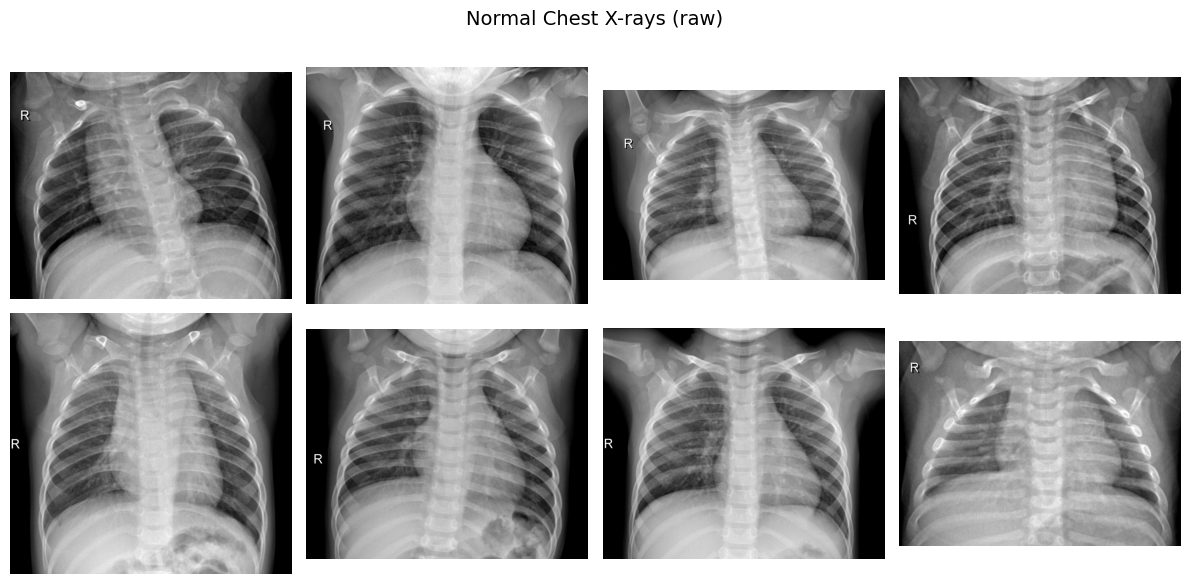

In [6]:
show_image_grid(normal_paths, "Normal Chest X-rays (raw)")

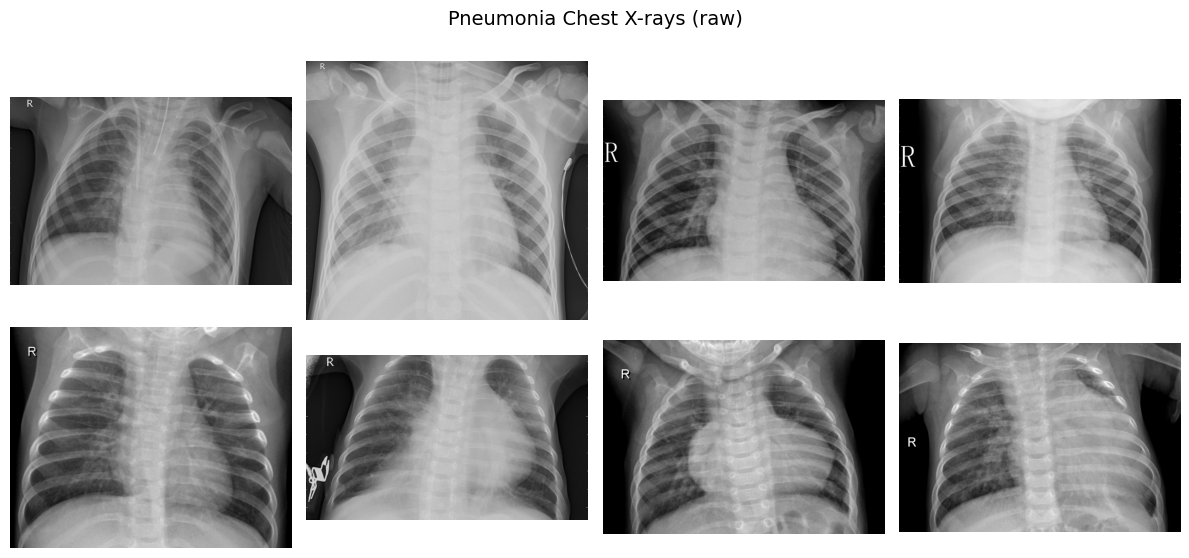

In [7]:
show_image_grid(pneumonia_paths, "Pneumonia Chest X-rays (raw)")

## Preprocessing

Resize to 64x64 and convert to grayscale. Small size keeps training fast and FID valid at 100 samples.

In [8]:
def preprocess_and_save(image_paths: list, output_dir: Path, size: int = 64):
    """Resize images to size x size grayscale and save as PNG."""
    output_dir.mkdir(parents=True, exist_ok=True)
    
    for i, img_path in enumerate(tqdm(image_paths, desc=f"Processing {output_dir.name}")):
        img = Image.open(img_path).convert('L')
        img = img.resize((size, size), Image.LANCZOS)
        
        # save as PNG to avoid compression artifacts
        output_path = output_dir / f"{i:04d}.png"
        img.save(output_path, 'PNG')
    
    return len(image_paths)

In [9]:
n_normal = preprocess_and_save(normal_paths, OUTPUT_NORMAL, IMG_SIZE)
print(f"Saved {n_normal} normal images to {OUTPUT_NORMAL}/")

Processing normal: 100%|██████████| 1341/1341 [00:09<00:00, 145.22it/s]

Saved 1341 normal images to normal/


In [10]:
n_pneumonia = preprocess_and_save(pneumonia_paths, OUTPUT_PNEUMONIA, IMG_SIZE)
print(f"Saved {n_pneumonia} pneumonia images to {OUTPUT_PNEUMONIA}/")

Processing pneumonia: 100%|██████████| 3875/3875 [00:08<00:00, 464.12it/s]

Saved 3875 pneumonia images to pneumonia/


## Verify Processed Images

In [11]:
processed_normal = get_image_paths(OUTPUT_NORMAL)
processed_pneumonia = get_image_paths(OUTPUT_PNEUMONIA)

print(f"Processed normal:    {len(processed_normal):,}")
print(f"Processed pneumonia: {len(processed_pneumonia):,}")

Processed normal:    1,341
Processed pneumonia: 3,875


In [12]:
# verify dimensions
sample_img = Image.open(processed_normal[0])
print(f"Sample image size: {sample_img.size}")
print(f"Sample image mode: {sample_img.mode}")

Sample image size: (64, 64)
Sample image mode: L


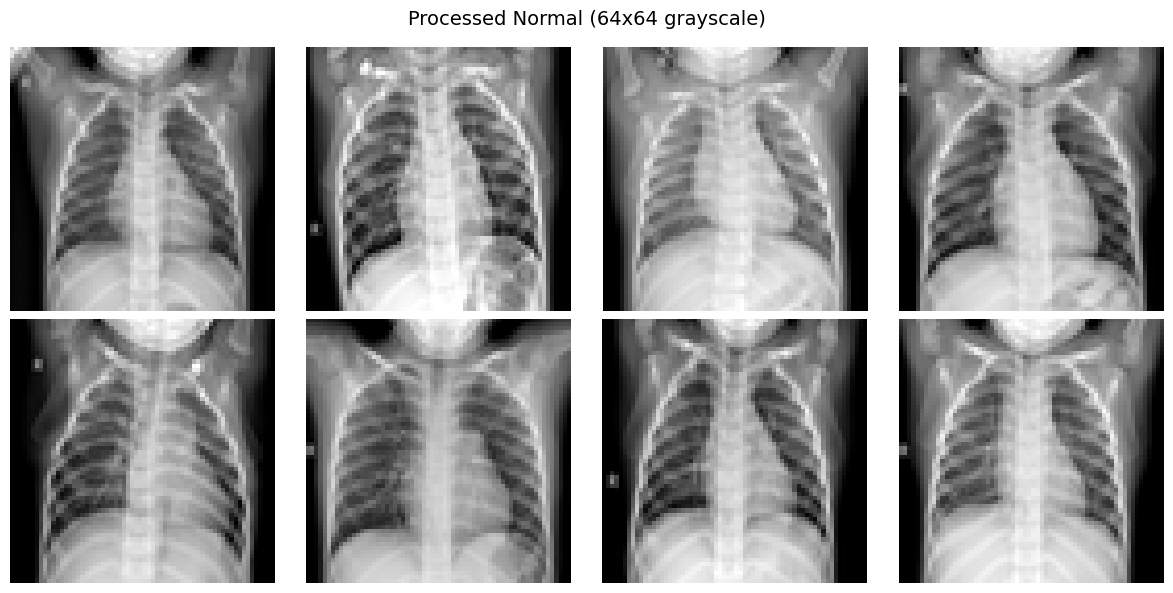

In [13]:
show_image_grid(processed_normal, "Processed Normal (64x64 grayscale)")

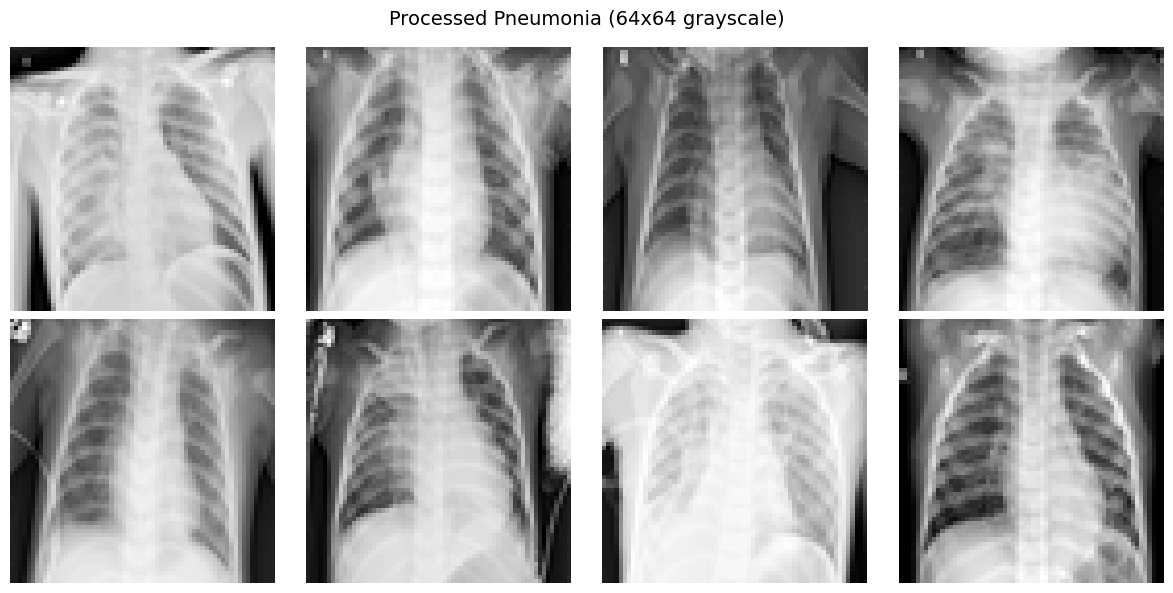

In [14]:
show_image_grid(processed_pneumonia, "Processed Pneumonia (64x64 grayscale)")

## Summary

Dataset ready for model training:
- `data/normal/` — 1341 images (64x64 grayscale PNG)
- `data/pneumonia/` — 3875 images (64x64 grayscale PNG)